In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import os
import glob
import sys
from tqdm import tqdm
import datetime
import gc
import numpy as np
import tensorflow as tf

In [52]:
config = {
    'project_path': 'drive/MyDrive/author-handwriting-recog',
    'dataset': 'complete_dataset_20260122-142244.tar.gz',
    'authors_range': range(204),
    'input_shape': (113, 113, 1),
    'embedding_dim': 512,
    'epochs': 10,
    'seed': 42,
}

In [4]:
sys.path.insert(0, config['project_path'])

In [5]:
sys.path

['drive/MyDrive/author-handwriting-recog',
 '/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython']

In [6]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 136.3 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=013288f90a2c0ec2299a44b750720400748f49bce9535ba5c1d0c46365ba6646
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [7]:
from src.io.exceptions import DeserializationError
from src.io.logging import LoggerFactory
from src import SelectiveDataLoader
from src.io import load

In [8]:
dataset_path = f"{config['project_path']}/data/datasets/{config['dataset']}"

In [9]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [10]:
logger = LoggerFactory.get_notebook_logger("code_1", log_dir=f"./logs_{current_time}")

In [11]:
!tar -xzf {dataset_path} -C ./

In [12]:
loader = SelectiveDataLoader(
        dataset_path="./complete_dataset_20260122-142244.zarr",
        load_fn=load
        )

09:03:07 - ZarrSerializer - INFO - Initialized with blosc compression (level 5)
09:03:07 - ZarrSerializer - INFO - ======================================================================
09:03:07 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
09:03:07 - ZarrSerializer - INFO - ======================================================================
09:03:07 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
09:03:07 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
09:03:07 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
09:03:07 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
09:03:07 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
09:03:07 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
09:03:07 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
09:03:07 - ZarrSerializer - INFO - ======================

In [13]:
from src.datasets import SubsetBuilder, PairGenerator, DataGenerator, TripletGenerator

In [14]:
subset_builder = SubsetBuilder(
    loader=loader,
)

In [15]:
subset = subset_builder.build(
    authors_range=config['authors_range'],
    show_progress_bar=True,
)

09:03:07 - ZarrSerializer - INFO - ======================================================================
09:03:07 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
09:03:07 - ZarrSerializer - INFO - ======================================================================
09:03:07 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
09:03:07 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
09:03:07 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
09:03:07 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
09:03:07 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
09:03:07 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
09:03:07 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
09:03:07 - ZarrSerializer - INFO - ======================================================================
09:03:07 - ZarrSerializer - INF

Loading train: 100%|██████████| 204/204 [01:06<00:00,  3.06it/s]


09:04:20 - ZarrSerializer - INFO - ======================================================================
09:04:20 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
09:04:20 - ZarrSerializer - INFO - ======================================================================
09:04:20 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
09:04:20 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
09:04:20 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
09:04:20 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
09:04:20 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
09:04:20 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
09:04:20 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
09:04:20 - ZarrSerializer - INFO - ======================================================================
09:04:20 - ZarrSerializer - INF

Loading validation: 100%|██████████| 204/204 [00:08<00:00, 23.79it/s]


09:04:30 - ZarrSerializer - INFO - ======================================================================
09:04:30 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
09:04:30 - ZarrSerializer - INFO - ======================================================================
09:04:30 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
09:04:30 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
09:04:30 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
09:04:30 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
09:04:30 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
09:04:30 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
09:04:30 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
09:04:30 - ZarrSerializer - INFO - ======================================================================
09:04:30 - ZarrSerializer - INF

Loading test: 100%|██████████| 204/204 [00:02<00:00, 88.26it/s]


In [57]:
train_triplet_gen = TripletGenerator(
    data=subset.splits['train'],
    batch_size=128,
    target_size=config['input_shape'][:2],
    shuffle=True,
    use_augmentation=True,
    seed=config['seed']
)

In [54]:
val_triplet_gen = TripletGenerator(
    data=subset.splits['validation'],
    batch_size=32,
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [55]:
test_triplet_gen = TripletGenerator(
    data=subset.splits['test'],
    batch_size=16,
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [58]:
len(train_triplet_gen), len(val_triplet_gen), len(test_triplet_gen)

(4961, 3226, 1602)

In [59]:
logger.info(f"Train samples: {train_triplet_gen.num_patches}")
logger.info(f"Validation samples: {val_triplet_gen.num_patches}")
logger.info(f"Test samples: {test_triplet_gen.num_patches}")
logger.info(f"Ratio: {train_triplet_gen.num_patches / val_triplet_gen.num_patches:.2f}")

INFO - Train samples: 634910
INFO - Validation samples: 103225
INFO - Test samples: 25622
INFO - Ratio: 6.15


In [60]:
train_stats = train_triplet_gen.get_statistics()
logger.info(f"Train samples: {train_stats["total_patches"]}")
logger.info(f"Avg patches per author: {train_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {train_stats["min_patches"]}")
logger.info(f"Max patches per author: {train_stats["max_patches"]}")

INFO - Train samples: 634910
INFO - Avg patches per author: 3112.30
INFO - Min patches per author: 792
INFO - Max patches per author: 3269


In [61]:
val_stats = val_triplet_gen.get_statistics()
logger.info(f"Val samples: {val_stats["total_patches"]}")
logger.info(f"Avg patches per author: {val_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {val_stats["min_patches"]}")
logger.info(f"Max patches per author: {val_stats["max_patches"]}")

INFO - Val samples: 103225
INFO - Avg patches per author: 506.00
INFO - Min patches per author: 143
INFO - Max patches per author: 533


In [62]:
test_stats = test_triplet_gen.get_statistics()
logger.info(f"Val samples: {test_stats["total_patches"]}")
logger.info(f"Avg patches per author: {test_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {test_stats["min_patches"]}")
logger.info(f"Max patches per author: {test_stats["max_patches"]}")

INFO - Val samples: 25622
INFO - Avg patches per author: 125.60
INFO - Min patches per author: 79
INFO - Max patches per author: 143


In [24]:
from src.models import (
    CNNBackbone,
    CNNTransformerBackbone,
    DeepCNNBackbone,
    build_siamese_model,
    build_embedding_model,
    ContrastiveLoss,
    BinaryCrossEntropyDistance,
    TripletLoss,
)
from src.models.training import ModelTrainer, get_default_callbacks
from src.models.evaluation import (
    ModelComparator,
    ModelEvaluator,
    plot_training_history,
    plot_comparison_metrics,
    plot_embeddings_tsne
)

In [67]:
cnn_trainer = ModelTrainer(
    backbone=DeepCNNBackbone(),
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_triplet_cnn",
    log_dir=f"./logs_{current_time}"
)

10:11:38 - siamese_triplet_cnn_trainer - INFO - Model trainer initialized: siamese_triplet_cnn
10:11:38 - siamese_triplet_cnn_trainer - INFO - Input shape: (113, 113, 1)
10:11:38 - siamese_triplet_cnn_trainer - INFO - Embedding dim: 512


In [68]:
cnn_trainer.build(model_type="triplet")

10:11:42 - siamese_triplet_cnn_trainer - INFO - Building models...
10:11:42 - siamese_triplet_cnn_trainer - INFO - Model built: triplet_model
10:11:42 - siamese_triplet_cnn_trainer - INFO - Total params: 3457088
10:11:42 - siamese_triplet_cnn_trainer - INFO - Trainable params: 3454336


In [69]:
cnn_trainer.embedding_model.summary()

Model: "siamese_triplet_cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 113, 113, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 113, 113, 96)   │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 113, 113, 96)   │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 113, 113, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 28, 28, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 14, 14, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 512)            │       131,58

 Total params: 3,457,088 (13.19 MB)

 Trainable params: 3,454,336 (13.18 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [70]:
cnn_trainer.siamese_model.summary()

Model: "triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_input        │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_input      │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_input      │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_triplet_cn… │ (None, 512)       │  3,457,088 │ anchor_input[0][… │
│ (Functional)        │                   │            │ positive_input[0… │
│                     │                   │            │ negative_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 3, 512)    │          0 │ siamese_triplet_… │
│                     │                   │            │ siamese_triplet_… │
│                     │                   │            │ siamese_triplet_… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,457,088 (13.19 MB)

 Trainable params: 3,454,336 (13.18 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [71]:
cnn_trainer.compile(loss=TripletLoss(margin=0.5))

10:12:06 - siamese_triplet_cnn_trainer - INFO - Compiling model...
10:12:06 - siamese_triplet_cnn_trainer - INFO - Model compiled
10:12:06 - siamese_triplet_cnn_trainer - INFO -   - Optimizer: Adam
10:12:06 - siamese_triplet_cnn_trainer - INFO -   - Learning rate: 0.0001
10:12:06 - siamese_triplet_cnn_trainer - INFO -   - Loss: TripletLoss
10:12:06 - siamese_triplet_cnn_trainer - INFO -   - Loss margin: 0.5


In [72]:
callbacks = get_default_callbacks(
    model_name="siamese_cnn",
    patience=4,
    reduce_lr_patience=2,
)

In [73]:
train_ds, train_steps = train_triplet_gen.to_dataset()
val_ds, val_steps = val_triplet_gen.to_dataset()

In [74]:
logger.info(f"Train steps: {train_steps}")
logger.info(f"Validation steps: {val_steps}")

INFO - Train steps: 4961
INFO - Validation steps: 3226


In [75]:
cnn_history = cnn_trainer.train(
    train_generator=train_ds,
    val_generator=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=config['epochs'],
    callbacks=callbacks,
    verbose=1
)

10:12:20 - siamese_triplet_cnn_trainer - INFO - Starting training for 10 epochs...
10:12:20 - siamese_triplet_cnn_trainer - INFO -   - Train batches: 4961
10:12:20 - siamese_triplet_cnn_trainer - INFO -   - Val batches: 3226
Epoch 1/10
4961/4961 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 0.4255
Epoch 1: val_loss improved from inf to 0.36963, saving model to checkpoints/siamese_cnn/best.keras
4961/4961 ━━━━━━━━━━━━━━━━━━━━ 1369s 274ms/step - loss: 0.4255 - val_loss: 0.3696 - learning_rate: 1.0000e-04
Epoch 2/10
4961/4961 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.3928
Epoch 2: val_loss improved from 0.36963 to 0.32763, saving model to checkpoints/siamese_cnn/best.keras
4961/4961 ━━━━━━━━━━━━━━━━━━━━ 1360s 274ms/step - loss: 0.3928 - val_loss: 0.3276 - learning_rate: 1.0000e-04
Epoch 3/10
4961/4961 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.3604
Epoch 3: val_loss improved from 0.32763 to 0.32221, saving model to checkpoints/siamese_cnn/best.keras
4961/4961 ━━━━━━━━━━━━━━━━━━━━ 1366s 

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

def plot_training_loss(history, title="Training Loss"):
    loss = history.history["loss"]
    val_loss = history.history.get("val_loss")

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Train Loss")
    if val_loss is not None:
        plt.plot(val_loss, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
plot_training_loss(
    cnn_history,
    title="Siamese DeepWritter – Contrastive Loss"
)

In [76]:
cnn_trainer.save(f"./models/siamese_triplet_cnn_{current_time}.keras")

11:46:47 - siamese_triplet_cnn_trainer - INFO - Model saved to models/siamese_triplet_cnn_20260204-090159.keras


In [77]:
cnn_trainer_new = ModelTrainer(
    backbone=DeepCNNBackbone(),
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_triplet_cnn",
    log_dir=f"./logs_{current_time}"
)
cnn_trainer_new.build(model_type="triplet")

11:46:49 - siamese_triplet_cnn_trainer - INFO - Model trainer initialized: siamese_triplet_cnn
11:46:49 - siamese_triplet_cnn_trainer - INFO - Input shape: (113, 113, 1)
11:46:49 - siamese_triplet_cnn_trainer - INFO - Embedding dim: 512
11:46:49 - siamese_triplet_cnn_trainer - INFO - Building models...
11:46:49 - siamese_triplet_cnn_trainer - INFO - Model built: triplet_model
11:46:49 - siamese_triplet_cnn_trainer - INFO - Total params: 3457088
11:46:49 - siamese_triplet_cnn_trainer - INFO - Trainable params: 3454336


In [78]:
cnn_trainer_new.siamese_model.load_weights(
    f"./models/siamese_triplet_cnn_{current_time}.keras"
)

In [79]:
cnn_evaluator = ModelEvaluator(
    model=cnn_trainer_new.siamese_model,
    model_name="siamese_triplet_cnn",
    embedding_model=cnn_trainer_new.embedding_model,
    model_type="triplet",
    log_dir=f"./logs_{current_time}"
)

In [80]:
cnn_evaluator.model.summary()

Model: "triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_input        │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_input      │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_input      │ (None, 113, 113,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_triplet_cn… │ (None, 512)       │  3,457,088 │ anchor_input[0][… │
│ (Functional)        │                   │            │ positive_input[0… │
│                     │                   │            │ negative_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_3 (Stack)     │ (None, 3, 512)    │          0 │ siamese_triplet_… │
│                     │                   │            │ siamese_triplet_… │
│                     │                   │            │ siamese_triplet_… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,457,088 (13.19 MB)

 Trainable params: 3,454,336 (13.18 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [81]:
cnn_evaluator.embedding_model.summary()

Model: "siamese_triplet_cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 113, 113, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 113, 113, 96)   │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 113, 113, 96)   │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 113, 113, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 28, 28, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 14, 14, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 14, 14, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 512)            │       131,58

 Total params: 3,457,088 (13.19 MB)

 Trainable params: 3,454,336 (13.18 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [82]:
test_ds, test_steps = test_triplet_gen.to_dataset()

In [83]:
test_results = cnn_evaluator.evaluate(
    test_generator=test_ds,
    steps=test_steps,
    distance_threshold=1.0
)

11:47:10 - siamese_triplet_cnn_evaluator - INFO - Evaluating siamese_triplet_cnn...
11:49:29 - siamese_triplet_cnn_evaluator - INFO - Evaluation completed:
11:49:29 - siamese_triplet_cnn_evaluator - INFO -   - Accuracy:  0.6404
11:49:29 - siamese_triplet_cnn_evaluator - INFO -   - AUC:       0.8412
11:49:29 - siamese_triplet_cnn_evaluator - INFO -   - Precision: 0.5839
11:49:29 - siamese_triplet_cnn_evaluator - INFO -   - Recall:    0.9771
11:49:29 - siamese_triplet_cnn_evaluator - INFO -   - F1-Score:  0.7310


In [141]:
from sklearn.metrics import (
         roc_curve, accuracy_score,
     precision_recall_fscore_support,
         f1_score, precision_recall_curve
)
import numpy as np
import matplotlib.pyplot as plt

# Obtener distancias
distances = test_results['distances']
y_true = test_results['y_true']

pos_distances = distances[y_true == 1]
neg_distances = distances[y_true == 0]

logger.info(f"\nPositive pairs (same author) - {len(   pos_distances)} samples:")
logger.info(f"  Mean:   {pos_distances.mean():.4f}")
logger.info(f"  Std:    {pos_distances.std():.4f}")
logger.info(f"  Median: {np.median(pos_distances):.4f}")
logger.info(f"  Q1:     {np.percentile(pos_distances, 25):.4f}")
logger.info(f"  Q3:     {np.percentile(pos_distances, 75):.4f}")
logger.info(f"  Min:    {pos_distances.min():.4f}")
logger.info(f"  Max:    {pos_distances.max():.4f}")

logger.info(f"\nNegative pairs (different authors) - {len(neg_distances)} samples:")
logger.info(f"  Mean:   {neg_distances.mean():.4f}")
logger.info(f"  Std:    {neg_distances.std():.4f}")
logger.info(f"  Median: {np.median(neg_distances):.4f}")
logger.info(f"  Q1:     {np.percentile(neg_distances, 25):.4f}")
logger.info(f"  Q3:     {np.percentile(neg_distances, 75):.4f}")
logger.info(f"  Min:    {neg_distances.min():.4f}")
logger.info(f"  Max:    {neg_distances.max():.4f}")

separation = neg_distances.mean() - pos_distances.mean()
overlap = max(0, pos_distances.max() - neg_distances.min())

logger.info(f"\nSeparation (neg_mean - pos_mean): {separation:.4f}")
logger.info(f"Overlap (pos_max - neg_min): {overlap:.4f}")
logger.info(f"Separation ratio: {separation / pos_distances.mean():.2%}")

fpr, tpr, thresholds_roc = roc_curve(y_true, - distances)
youden_j = tpr - fpr
optimal_idx_youden = np.argmax(youden_j)
optimal_threshold_youden = -thresholds_roc[
optimal_idx_youden]

logger.info(f"\nMethod 1: Youden's J (TPR - FPR)")
logger.info(f"  Optimal threshold: {optimal_threshold_youden:.4f}")
logger.info(f"  TPR: {tpr[optimal_idx_youden]:.4f}")
logger.info(f"  FPR: {fpr[optimal_idx_youden]:.4f}")
logger.info(f"  Youden's J: {youden_j[optimal_idx_youden]:.4f}")

logger.info(f"\nMethod 2: Maximize F1-Score")
thresholds_to_test = np.linspace(distances.min(), distances.max(), 300)
best_f1 = 0
best_threshold_f1 = 0
best_metrics_f1 = {}

for thresh in thresholds_to_test:
    y_pred = (distances < thresh).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
             y_true, y_pred, average='binary', zero_division=0
         )

    if f1 > best_f1:
      best_f1 = f1
      best_threshold_f1 = thresh
      best_metrics_f1 = {
                 'accuracy': acc,
                 'precision': prec,
                 'recall': rec,
                 'f1': f1
      }

optimal_threshold_f1 = best_threshold_f1

logger.info(f"  Optimal threshold: {optimal_threshold_f1:.4f}")
logger.info(f"  Accuracy:  {best_metrics_f1['accuracy']:.4f}")
logger.info(f"  Precision: {best_metrics_f1['precision']:.4f}")
logger.info(f"  Recall:    {best_metrics_f1['recall']:.4f}")
logger.info(f"  F1-Score:  {best_metrics_f1['f1']:.4f}")

best_acc = 0
best_threshold_acc = 0
best_metrics_acc = {}

for thresh in thresholds_to_test:
    y_pred = (distances < thresh).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
             y_true, y_pred, average='binary', zero_division=0
         )

    if acc > best_acc:
             best_acc = acc
             best_threshold_acc = thresh
             best_metrics_acc = {
                 'accuracy': acc,
                 'precision': prec,
                 'recall': rec,
                 'f1': f1
             }

optimal_threshold_acc = best_threshold_acc

logger.info(f"  Optimal threshold: {optimal_threshold_acc:.4f}")
logger.info(f"  Accuracy:  {best_metrics_acc['accuracy']:.4f}")
logger.info(f"  Precision: {best_metrics_acc['precision']:.4f}")
logger.info(f"  Recall:    {best_metrics_acc['recall']:.4f}")
logger.info(f"  F1-Score:  {best_metrics_acc['f1']:.4f}")

logger.info(f"\n{'Method':<20} {'Threshold':<12} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
logger.info("-"*80)
logger.info(f"{'Youden (TPR-FPR)':<20} {optimal_threshold_youden:<12.4f} ", end="")
# Calcular métricas para Youden
y_pred_youden = (distances < optimal_threshold_youden).astype(int)
acc_y = accuracy_score(y_true, y_pred_youden)
prec_y, rec_y, f1_y, _ = precision_recall_fscore_support(y_true, y_pred_youden, average='binary')
logger.info(f"{acc_y:<10.4f} {prec_y:<10.4f} {rec_y:<10.4f} {f1_y:<10.4f}")
logger.info(f"{'Max F1-Score':<20} {optimal_threshold_f1:<12.4f} {best_metrics_f1['accuracy']:<10.4f} {best_metrics_f1['precision']:<10.4f} {best_metrics_f1['recall']:<10.4f} {best_metrics_f1['f1']:<10.4f}")
logger.info(f"{'Max Accuracy':<20} {optimal_threshold_acc:<12.4f} {best_metrics_acc['accuracy']:<10.4f} {best_metrics_acc['precision']:<10.4f} {best_metrics_acc['recall']:<10.4f} {best_metrics_acc['f1']:<10.4f}")

INFO - 
Positive pairs (same author) - 25632 samples:
INFO -   Mean:   0.5731
INFO -   Std:    0.1912
INFO -   Median: 0.5562
INFO -   Q1:     0.4334
INFO -   Q3:     0.6959
INFO -   Min:    0.0789
INFO -   Max:    1.3088
INFO - 
Negative pairs (different authors) - 25632 samples:
INFO -   Mean:   0.8712
INFO -   Std:    0.2215
INFO -   Median: 0.8758
INFO -   Q1:     0.7107
INFO -   Q3:     1.0360
INFO -   Min:    0.1702
INFO -   Max:    1.5529
INFO - 
Separation (neg_mean - pos_mean): 0.2981
INFO - Overlap (pos_max - neg_min): 1.1386
INFO - Separation ratio: 52.01%
INFO - 
Method 1: Youden's J (TPR - FPR)
INFO -   Optimal threshold: 0.7168
INFO -   TPR: 0.7784
INFO -   FPR: 0.2580
INFO -   Youden's J: 0.5204
INFO - 
Method 2: Maximize F1-Score
INFO -   Optimal threshold: 0.7987
INFO -   Accuracy:  0.7481
INFO -   Precision: 0.6989
INFO -   Recall:    0.8720
INFO -   F1-Score:  0.7759
INFO -   Optimal threshold: 0.7148
INFO -   Accuracy:  0.7599
INFO -   Precision: 0.7519
INFO -   Rec

TypeError: Logger._log() got an unexpected keyword argument 'end'

In [84]:
distances = test_results['distances']
y_true = test_results['y_true']

In [85]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, 1 - (distances / distances.max()))
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx] * distances.max()

logger.info(f"Optimal threshold: {optimal_threshold:.4f}")

INFO - Optimal threshold: 0.8361


In [86]:
test_results_optimal = cnn_evaluator.evaluate(
    test_generator=test_ds,
    steps=test_steps,
    distance_threshold=optimal_threshold
)

11:49:51 - siamese_triplet_cnn_evaluator - INFO - Evaluating siamese_triplet_cnn...
11:52:09 - siamese_triplet_cnn_evaluator - INFO - Evaluation completed:
11:52:09 - siamese_triplet_cnn_evaluator - INFO -   - Accuracy:  0.7304
11:52:09 - siamese_triplet_cnn_evaluator - INFO -   - AUC:       0.8383
11:52:09 - siamese_triplet_cnn_evaluator - INFO -   - Precision: 0.6712
11:52:09 - siamese_triplet_cnn_evaluator - INFO -   - Recall:    0.9032
11:52:09 - siamese_triplet_cnn_evaluator - INFO -   - F1-Score:  0.7701


In [87]:
distances_optimal = test_results_optimal['distances']
y_true_optimal = test_results_optimal['y_true']

INFO - Positive pairs - mean: 0.5744, std: 0.1898
INFO - Negative pairs - mean: 0.8681, std: 0.2218


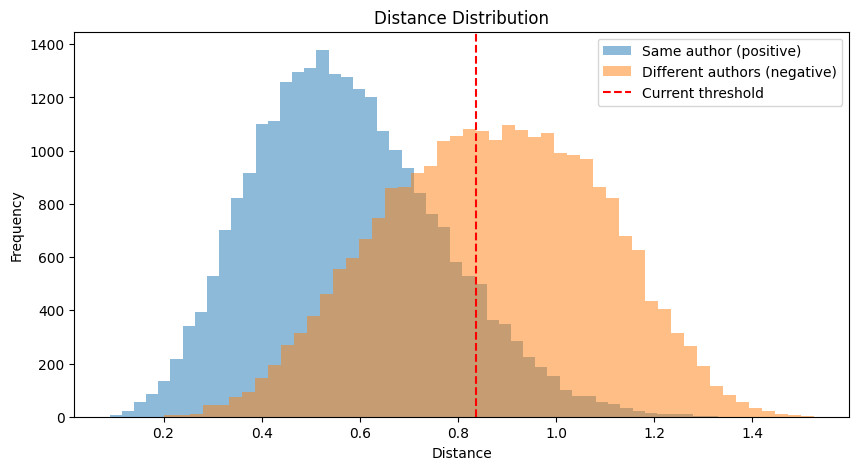

In [88]:
import matplotlib.pyplot as plt

pos_distances = distances_optimal[y_true_optimal == 1]
neg_distances = distances_optimal[y_true_optimal == 0]

logger.info(f"Positive pairs - mean: {pos_distances.mean():.4f}, std: {pos_distances.std():.4f}")
logger.info(f"Negative pairs - mean: {neg_distances.mean():.4f}, std: {neg_distances.std():.4f}")

# Plot histograma
plt.figure(figsize=(10, 5))
plt.hist(pos_distances, bins=50, alpha=0.5, label='Same author (positive)')
plt.hist(neg_distances, bins=50, alpha=0.5, label='Different authors (negative)')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label='Current threshold')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distance Distribution')
plt.show()

In [89]:
from src.datasets import DataGenerator

In [90]:
test_gen = DataGenerator(
    data=subset.splits['test'],
    batch_size=32,
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed']
)

In [91]:
test_ds, test_steps = test_gen.to_dataset()

In [92]:
all_embeddings: list[np.ndarray] = []
all_author_ids: list[np.ndarray] = []

for X, y in test_ds.take(test_steps):
    emb = cnn_evaluator.embedding_model.predict(X, verbose=0)
    all_embeddings.append(emb)
    all_author_ids.append(y)

embeddings = np.concatenate(all_embeddings, axis=0)   # (N, D)
author_ids = np.concatenate(all_author_ids, axis=0)   # (N,)

In [93]:
from collections import defaultdict

def build_gallery(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
) -> dict[int, np.ndarray]:

    by_author: dict[int, list[np.ndarray]] = defaultdict(list)

    for emb, author_id in zip(embeddings, author_ids):
        by_author[int(author_id)].append(emb)

    gallery = {
        author_id: np.mean(np.stack(author_embs), axis=0)
        for author_id, author_embs in by_author.items()
    }

    return gallery

In [94]:
gallery = build_gallery(embeddings, author_ids)

In [95]:
def identify_author(
    author_embeddings: np.ndarray,
    gallery: dict[int, np.ndarray],
) -> dict[str, any]:

    scores: dict[int, float] = {}

    for author_id, gallery_emb in gallery.items():
        distances = np.linalg.norm(author_embeddings - gallery_emb, axis=1)
        scores[author_id] = float(distances.mean())

    pred_author = min(scores, key=scores.get)

    return {
        "pred_author_id": pred_author,
        "scores": scores,
        "mean_distance": scores[pred_author],
    }

In [96]:
from sklearn.metrics import accuracy_score

def evaluate_identification(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    gallery: dict[int, np.ndarray],
    min_patches: int = 3,
) -> dict[str, any]:

    y_true: list[int] = []
    y_pred: list[int] = []
    details: list[dict[str, any]] = []

    for author_id in np.unique(author_ids):
        idx = np.where(author_ids == author_id)[0]

        if len(idx) < min_patches:
            continue

        author_embs = embeddings[idx]
        res = identify_author(author_embs, gallery)

        y_true.append(author_id)
        y_pred.append(res["pred_author_id"])

        details.append({
            "true_author_id": author_id,
            "pred_author_id": res["pred_author_id"],
            "correct": author_id == res["pred_author_id"],
            "mean_distance": res["mean_distance"],
        })

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "num_authors": len(y_true),
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "details": details,
    }

In [97]:
import pandas as pd

def identification_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    # Ensure proper dtypes
    df["true_author_id"] = df["true_author_id"].astype(int)
    df["pred_author_id"] = df["pred_author_id"].astype(int)
    df["correct"] = df["correct"].astype(bool)
    df["mean_distance"] = df["mean_distance"].astype(float)

    return df

In [98]:
def extract_identification_summary(res: dict) -> dict[str, float | int]:
    """
    Extract high-level identification metrics.
    """
    return {
        "accuracy": res["accuracy"],
        "num_authors": res["num_authors"],
    }

In [99]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
    normalize: bool = True
) -> None:
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(
        y_true,
        y_pred,
        normalize='true' if normalize else None,
    )
    fig, ax = plt.subplots(figsize=(8, 8))
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax, ax=ax)

    ax.set_title(f"{title} (Acc: {acc:.2%})", fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()

In [100]:
identification_results = evaluate_identification(
    embeddings,
    author_ids,
    gallery,
)

In [101]:
res = identification_results_to_df(identification_results)
summary = extract_identification_summary(identification_results)

In [102]:
logger.info(f"Identification summary: {summary}")

INFO - Identification summary: {'accuracy': 1.0, 'num_authors': 204}


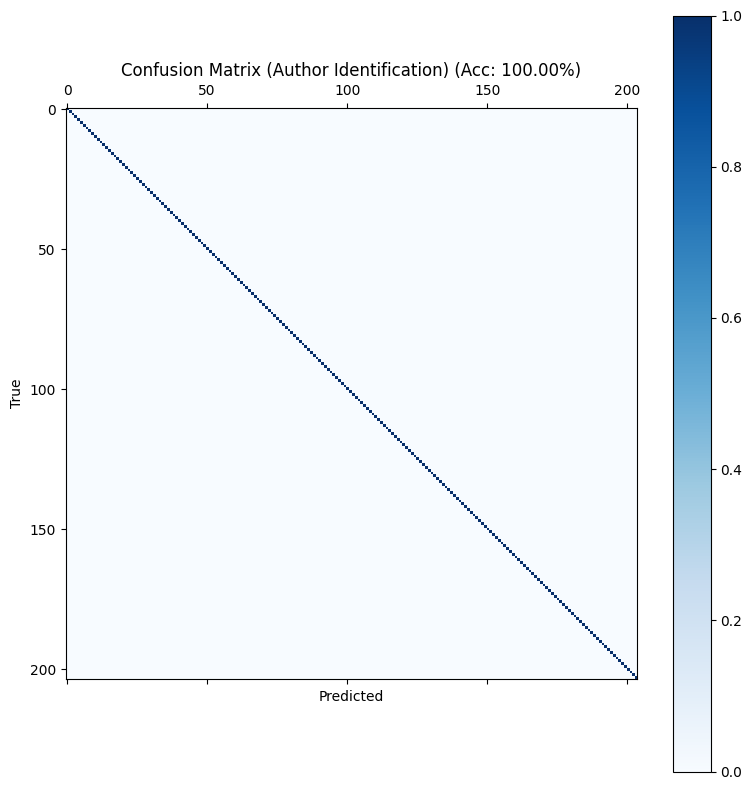

In [103]:
plot_confusion_matrix(
    identification_results["y_true"],
    identification_results["y_pred"],
    title="Confusion Matrix (Author Identification)",
    normalize=True,
)

In [104]:
res

,true_author_id,pred_author_id,correct,mean_distance
0,0,0,True,0.255282
1,1,1,True,0.272495
2,2,2,True,0.430395
3,3,3,True,0.472251
4,4,4,True,0.490099
...,...,...,...,...
199,199,199,True,0.510259
200,200,200,True,0.443216
201,201,201,True,0.468707
202,202,202,True,0.301513


In [105]:
def voting_for_author(
    embeddings: np.ndarray,
    distance_threshold: float,
) -> dict[str, any]:

    votes_same, votes_diff = 0, 0
    distances = []

    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            d = np.linalg.norm(embeddings[i] - embeddings[j])
            distances.append(d)

            if d < distance_threshold:
                votes_same += 1
            else:
                votes_diff += 1

    total = votes_same + votes_diff

    return {
        "votes_same": votes_same,
        "votes_diff": votes_diff,
        "confidence": votes_same / total if total > 0 else 0.0,
        "mean_distance": float(np.mean(distances)),
        "std_distance": float(np.std(distances)),
        "num_pairs": total,
    }

In [106]:
def evaluate_voting(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    distance_threshold: float,
    min_patches: int = 3,
) -> dict[str, any]:

    details = []

    for author_id in np.unique(author_ids):
        idx = np.where(author_ids == author_id)[0]

        if len(idx) < min_patches:
            continue

        res = voting_for_author(
            embeddings[idx],
            distance_threshold,
        )

        details.append({
            "author_id": author_id,
            **res,
        })

    return {
        "num_authors": len(details),
        "details": details,
    }

In [107]:
import pandas as pd

def voting_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    # Ensure proper dtypes
    df["author_id"] = df["author_id"].astype(int)
    df["votes_same"] = df["votes_same"].astype(int)
    df["votes_diff"] = df["votes_diff"].astype(int)
    df["confidence"] = df["confidence"].astype(float)
    df["mean_distance"] = df["mean_distance"].astype(float)
    df["std_distance"] = df["std_distance"].astype(float)
    df["num_pairs"] = df["num_pairs"].astype(int)

    return df

In [108]:
voting_results = evaluate_voting(
    embeddings,
    author_ids,
    distance_threshold=optimal_threshold,
)

In [109]:
v_results = voting_results_to_df(voting_results)

In [110]:
v_results

,author_id,votes_same,votes_diff,confidence,mean_distance,std_distance,num_pairs
0,0,5778,0,1.000000,0.362401,0.111094,5778
1,1,7498,5,0.999334,0.387110,0.120356,7503
2,2,7577,938,0.889841,0.607448,0.179873,8515
3,3,7369,1811,0.802723,0.667493,0.200696,9180
4,4,6405,1596,0.800525,0.685456,0.185675,8001
...,...,...,...,...,...,...,...
199,199,5399,1861,0.743664,0.716168,0.177612,7260
200,200,6618,885,0.882047,0.628417,0.173215,7503
201,201,6684,1066,0.862452,0.653403,0.168479,7750
202,202,8244,141,0.983184,0.428707,0.145272,8385


In [76]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def display_embedding_subset(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    num_authors: int,
    title: str,
    reducer,
    seed: int = 42,
) -> None:
    all_classes = np.unique(author_ids)
    rng = np.random.default_rng(seed)

    selected_classes = rng.choice(all_classes, size=num_authors, replace=False)

    mask = np.isin(author_ids, selected_classes)
    subset_embeddings = embeddings[mask]
    subset_author_ids = author_ids[mask]

    X_reduced = reducer.fit_transform(subset_embeddings)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=subset_author_ids, cmap='tab20', s=10)
    plt.colorbar(scatter)
    plt.title(f"{title} - {num_authors} Classes")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()

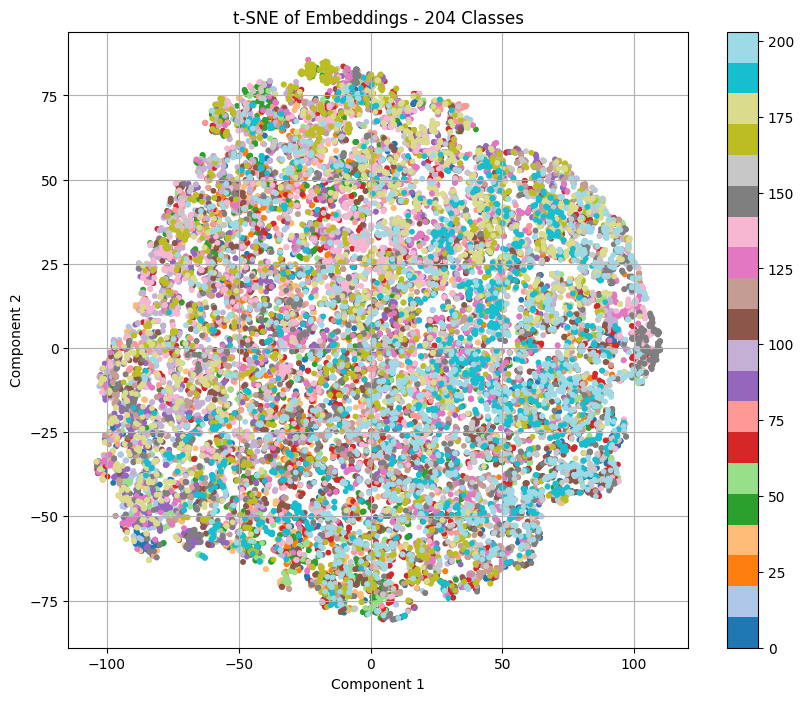

In [77]:
_reducer = TSNE(n_components=2, perplexity=30, random_state=config['seed'])
display_embedding_subset(
    embeddings,
    author_ids,
    num_authors=204,
    title="t-SNE of Embeddings",
    reducer=_reducer,
    seed=config['seed'],
)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


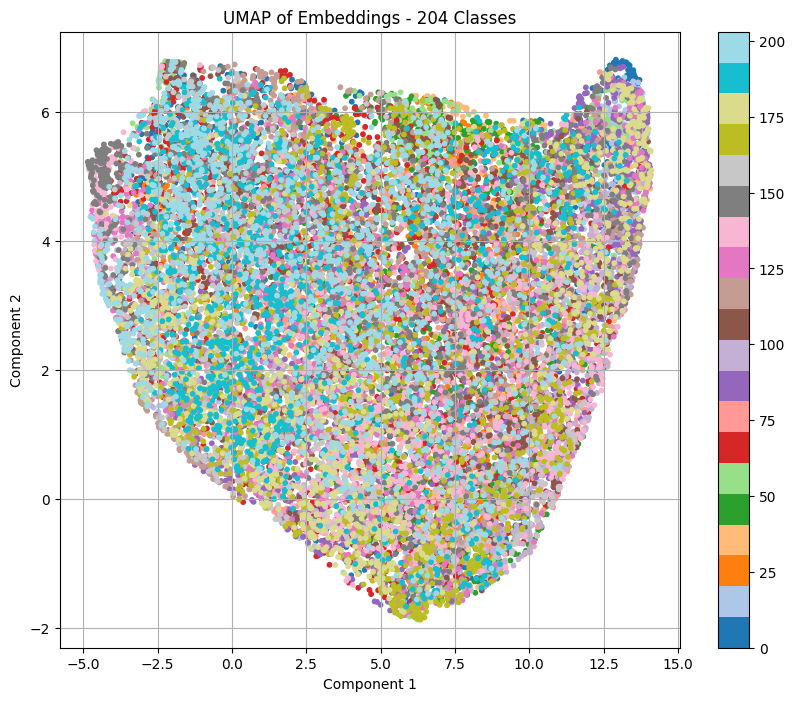

In [78]:
import umap.umap_ as umap

emb = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
_reducer = umap.UMAP(n_neighbors=20, min_dist=0.2, n_components=2, random_state=config['seed'])

display_embedding_subset(
    embeddings=emb,
    author_ids=author_ids,
    num_authors=204,
    title="UMAP of Embeddings",
    reducer=_reducer,
    seed=config['seed'],
)

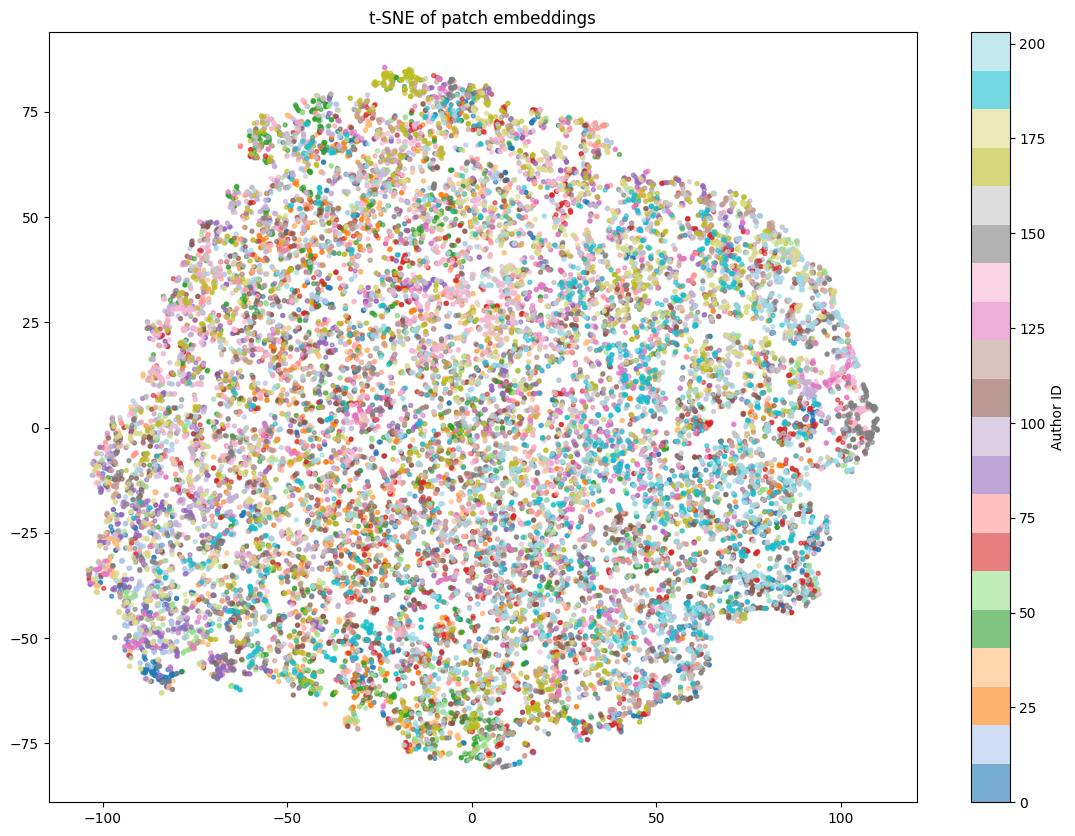

In [79]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=config['seed'],
)

emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(14, 10))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=author_ids,
    cmap="tab20",
    s=8,
    alpha=0.6,
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of patch embeddings")
plt.show()

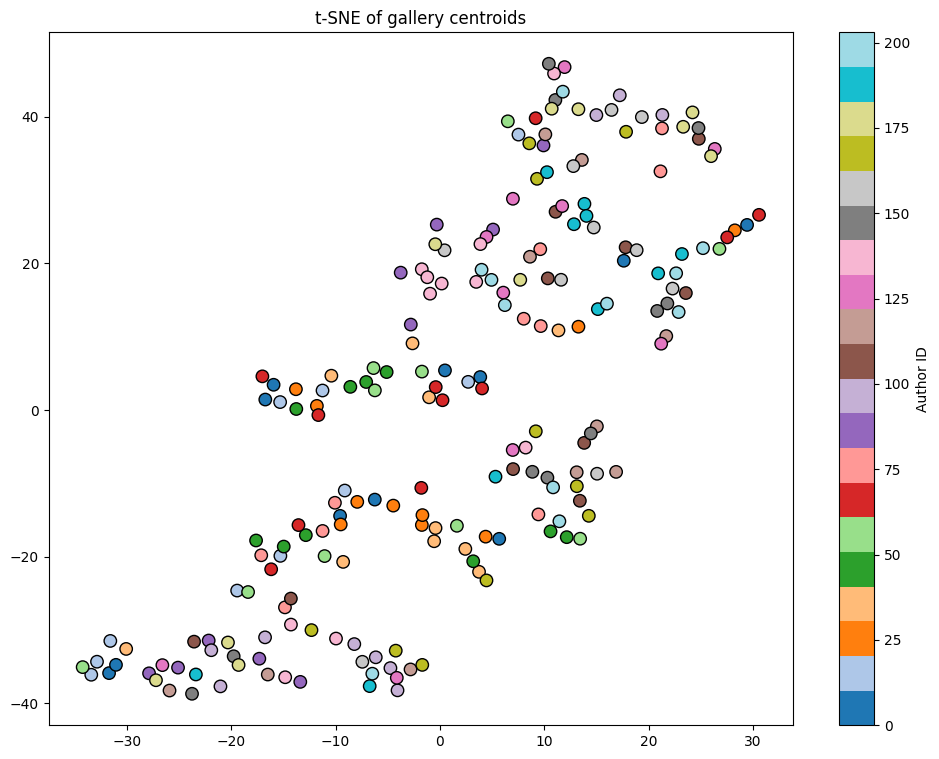

In [112]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

gallery_embeddings = np.stack(list(gallery.values()))
gallery_author_ids = np.array(list(gallery.keys()))

tsne = TSNE(
    n_components=2,
    perplexity=10,
    max_iter=1000,
    random_state=config['seed'],
)

gallery_2d = tsne.fit_transform(gallery_embeddings)

plt.figure(figsize=(12, 9))
plt.scatter(
    gallery_2d[:, 0],
    gallery_2d[:, 1],
    c=gallery_author_ids,
    cmap="tab20",
    s=80,
    edgecolors="black",
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of gallery centroids")
plt.show()

In [113]:
eval_subset = subset_builder.build(
    authors_range=range(204, 407),
    show_progress_bar=True,
)

11:54:44 - ZarrSerializer - INFO - ======================================================================
11:54:44 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
11:54:44 - ZarrSerializer - INFO - ======================================================================
11:54:44 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
11:54:44 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
11:54:44 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
11:54:44 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
11:54:44 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
11:54:44 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
11:54:44 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
11:54:44 - ZarrSerializer - INFO - ======================================================================
11:54:44 - ZarrSerializer - INF

Loading train: 100%|██████████| 203/203 [01:02<00:00,  3.23it/s]


11:55:53 - ZarrSerializer - INFO - ======================================================================
11:55:53 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
11:55:53 - ZarrSerializer - INFO - ======================================================================
11:55:53 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
11:55:53 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
11:55:53 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
11:55:53 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
11:55:53 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
11:55:53 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
11:55:53 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
11:55:53 - ZarrSerializer - INFO - ======================================================================
11:55:53 - ZarrSerializer - INF

Loading validation: 100%|██████████| 203/203 [00:09<00:00, 22.51it/s]


11:56:04 - ZarrSerializer - INFO - ======================================================================
11:56:04 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
11:56:04 - ZarrSerializer - INFO - ======================================================================
11:56:04 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
11:56:04 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
11:56:04 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
11:56:04 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
11:56:04 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
11:56:04 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
11:56:04 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
11:56:04 - ZarrSerializer - INFO - ======================================================================
11:56:04 - ZarrSerializer - INF

Loading test: 100%|██████████| 203/203 [00:01<00:00, 102.54it/s]


In [118]:
eval_test_triplet_gen = TripletGenerator(
    data=eval_subset.splits['test'],
    batch_size=16,
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed'],
)

In [119]:
test_ds, test_steps = eval_test_triplet_gen.to_dataset()

In [120]:
eval_test_results = cnn_evaluator.evaluate(
    test_generator=test_ds,
    steps=test_steps,
    distance_threshold=1.0,
)

11:57:12 - siamese_triplet_cnn_evaluator - INFO - Evaluating siamese_triplet_cnn...
11:59:31 - siamese_triplet_cnn_evaluator - INFO - Evaluation completed:
11:59:31 - siamese_triplet_cnn_evaluator - INFO -   - Accuracy:  0.6243
11:59:31 - siamese_triplet_cnn_evaluator - INFO -   - AUC:       0.8285
11:59:31 - siamese_triplet_cnn_evaluator - INFO -   - Precision: 0.5726
11:59:31 - siamese_triplet_cnn_evaluator - INFO -   - Recall:    0.9798
11:59:31 - siamese_triplet_cnn_evaluator - INFO -   - F1-Score:  0.7228


In [121]:
distances = eval_test_results['distances']
y_true = eval_test_results['y_true']

In [122]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, 1 - (distances / distances.max()))
optimal_idx = np.argmax(tpr - fpr)
new_optimal_threshold = thresholds[optimal_idx] * distances.max()

logger.info(f"Optimal threshold: {new_optimal_threshold:.4f}")

INFO - Optimal threshold: 0.8560


In [123]:
eval_test_results_opt = cnn_evaluator.evaluate(
    test_generator=test_ds,
    steps=test_steps,
    distance_threshold=new_optimal_threshold,
)

11:59:31 - siamese_triplet_cnn_evaluator - INFO - Evaluating siamese_triplet_cnn...
12:01:51 - siamese_triplet_cnn_evaluator - INFO - Evaluation completed:
12:01:51 - siamese_triplet_cnn_evaluator - INFO -   - Accuracy:  0.7086
12:01:51 - siamese_triplet_cnn_evaluator - INFO -   - AUC:       0.8280
12:01:51 - siamese_triplet_cnn_evaluator - INFO -   - Precision: 0.6455
12:01:51 - siamese_triplet_cnn_evaluator - INFO -   - Recall:    0.9252
12:01:51 - siamese_triplet_cnn_evaluator - INFO -   - F1-Score:  0.7605


In [124]:
distances_opt = eval_test_results_opt['distances']
y_true_opt = eval_test_results_opt['y_true']

INFO - Positive pairs - mean: 0.5499, std: 0.1955
INFO - Negative pairs - mean: 0.8405, std: 0.2288


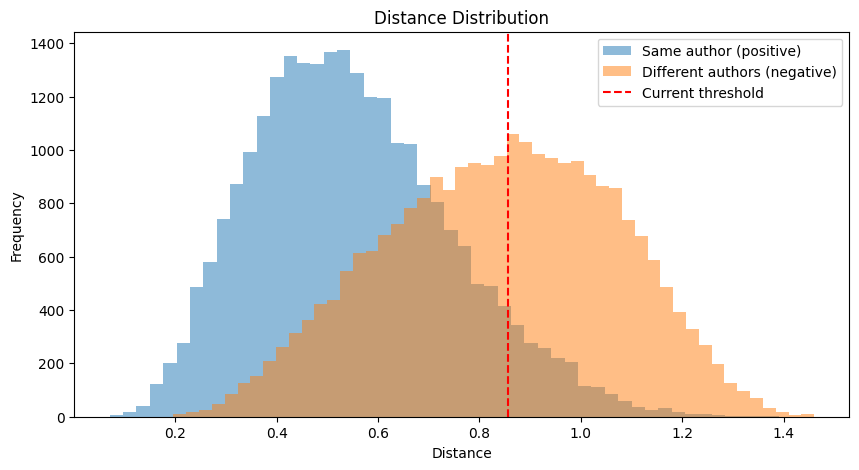

In [125]:
import matplotlib.pyplot as plt

pos_distances = distances_opt[y_true_opt == 1]
neg_distances = distances_opt[y_true_opt == 0]

logger.info(f"Positive pairs - mean: {pos_distances.mean():.4f}, std: {pos_distances.std():.4f}")
logger.info(f"Negative pairs - mean: {neg_distances.mean():.4f}, std: {neg_distances.std():.4f}")

# Plot histograma
plt.figure(figsize=(10, 5))
plt.hist(pos_distances, bins=50, alpha=0.5, label='Same author (positive)')
plt.hist(neg_distances, bins=50, alpha=0.5, label='Different authors (negative)')
plt.axvline(x=new_optimal_threshold, color='r', linestyle='--', label='Current threshold')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distance Distribution')
plt.show()

In [126]:
eval_test_gen = DataGenerator(
    data=eval_subset.splits['test'],
    batch_size=16,
    target_size=config['input_shape'][:2],
    use_augmentation=False,
    shuffle=False,
    seed=config['seed'],
)

In [127]:
eval_test_ds, eval_test_steps = eval_test_gen.to_dataset()

In [128]:
all_embeddings: list[np.ndarray] = []
all_author_ids: list[np.ndarray] = []

for X, y in eval_test_ds.take(eval_test_steps):
    emb = cnn_evaluator.embedding_model.predict(X, verbose=0)
    all_embeddings.append(emb)
    all_author_ids.append(y)

embeddings = np.concatenate(all_embeddings, axis=0)   # (N, D)
author_ids = np.concatenate(all_author_ids, axis=0)   # (N,)

In [129]:
eval_gallery = build_gallery(embeddings, author_ids)

In [130]:
eval_identification_results = evaluate_identification(
    embeddings,
    author_ids,
    eval_gallery,
)

In [131]:
eval_res = identification_results_to_df(eval_identification_results)
eval_summary = extract_identification_summary(eval_identification_results)

In [132]:
logger.info(f"Identification summary: {eval_summary}")

INFO - Identification summary: {'accuracy': 1.0, 'num_authors': 203}


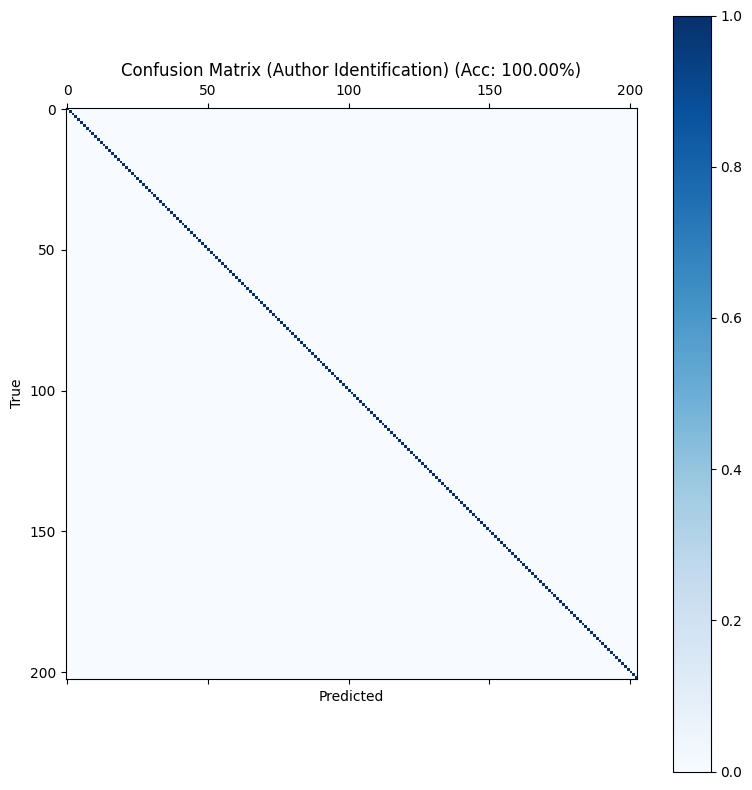

In [133]:
plot_confusion_matrix(
    eval_identification_results["y_true"],
    eval_identification_results["y_pred"],
    title="Confusion Matrix (Author Identification)",
    normalize=True,
)

In [134]:
eval_res

,true_author_id,pred_author_id,correct,mean_distance
0,0,0,True,0.468431
1,1,1,True,0.409302
2,2,2,True,0.383901
3,3,3,True,0.534055
4,4,4,True,0.447800
...,...,...,...,...
198,198,198,True,0.501215
199,199,199,True,0.386945
200,200,200,True,0.228951
201,201,201,True,0.456476


In [135]:
eval_voting_results = evaluate_voting(
    embeddings,
    author_ids,
    distance_threshold=new_optimal_threshold,
)

In [136]:
eval_results = voting_results_to_df(eval_voting_results)

In [137]:
eval_results

,author_id,votes_same,votes_diff,confidence,mean_distance,std_distance,num_pairs
0,0,7763,1148,0.871170,0.658068,0.172171,8911
1,1,7022,359,0.951362,0.579138,0.161281,7381
2,2,7730,398,0.951033,0.545163,0.175892,8128
3,3,6136,2642,0.699020,0.746962,0.203496,8778
4,4,9160,993,0.902196,0.630979,0.167876,10153
...,...,...,...,...,...,...,...
198,198,4424,1247,0.780109,0.705841,0.192137,5671
199,199,5564,107,0.981132,0.542988,0.142420,5671
200,200,6216,0,1.000000,0.324750,0.092453,6216
201,201,6152,1351,0.819939,0.639511,0.217570,7503


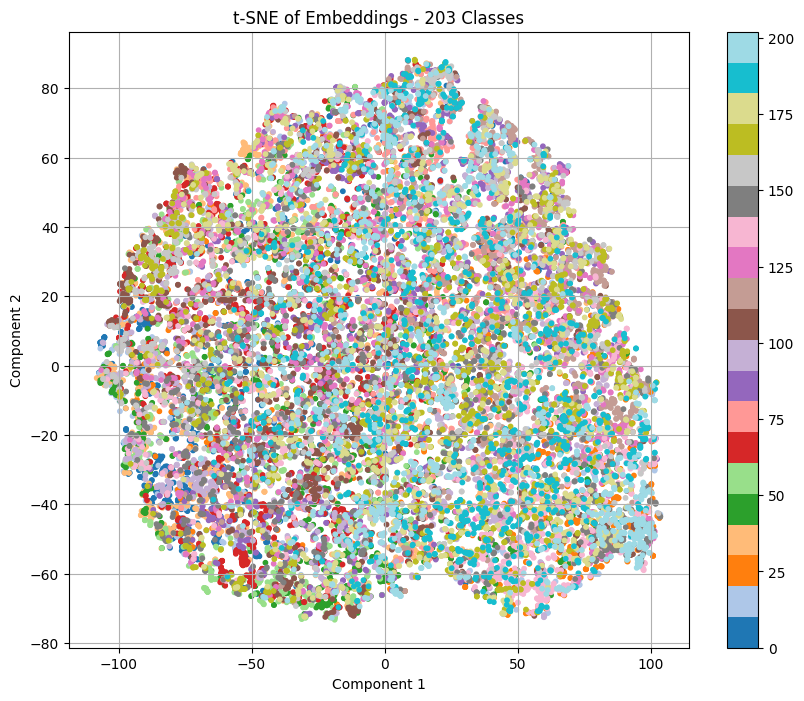

In [104]:
_reducer = TSNE(n_components=2, perplexity=30, random_state=config['seed'])
display_embedding_subset(
    embeddings,
    author_ids,
    num_authors=203,
    title="t-SNE of Embeddings",
    reducer=_reducer,
    seed=config['seed'],
)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


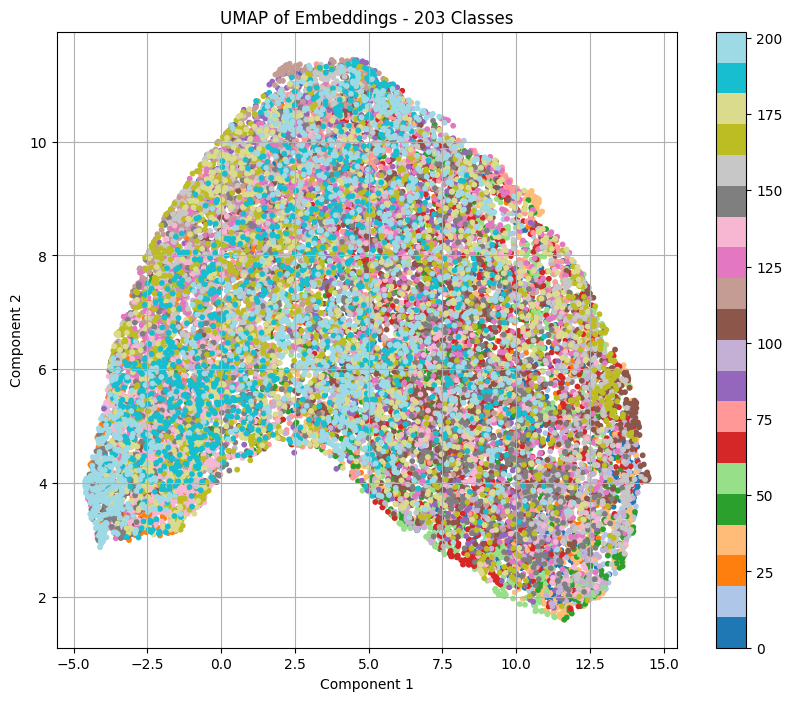

In [105]:
emb = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
_reducer = umap.UMAP(n_neighbors=20, min_dist=0.2, n_components=2, random_state=config['seed'])

display_embedding_subset(
    embeddings=emb,
    author_ids=author_ids,
    num_authors=203,
    title="UMAP of Embeddings",
    reducer=_reducer,
    seed=config['seed'],
)

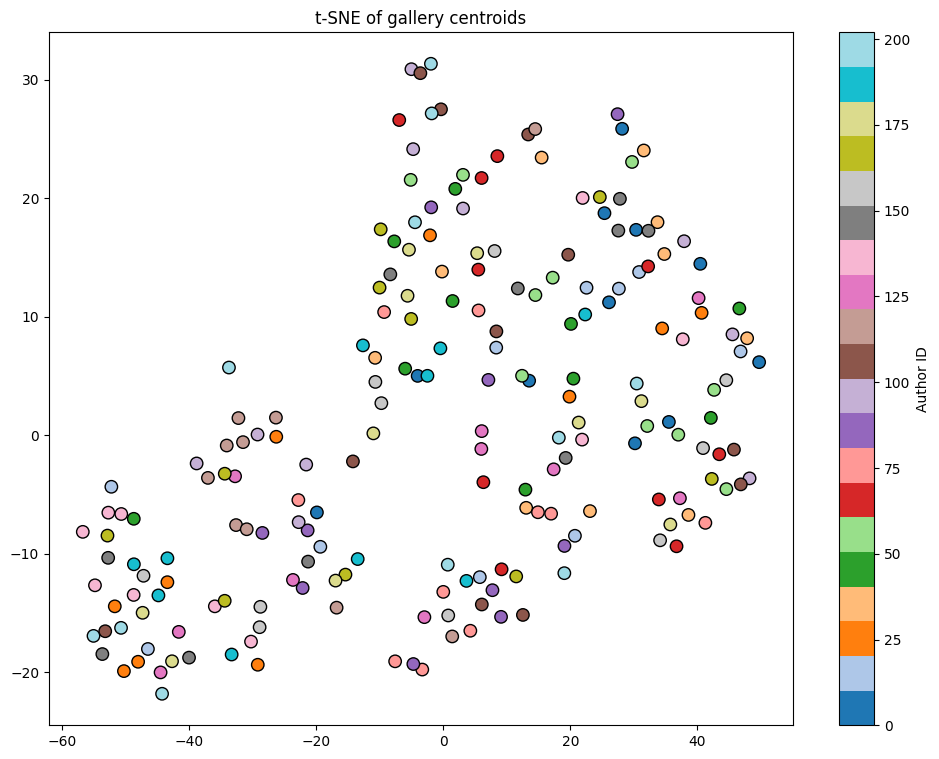

In [138]:
gallery_embeddings = np.stack(list(eval_gallery.values()))
gallery_author_ids = np.array(list(eval_gallery.keys()))

tsne = TSNE(
    n_components=2,
    perplexity=10,
    max_iter=1000,
    random_state=config['seed'],
)

gallery_2d = tsne.fit_transform(gallery_embeddings)

plt.figure(figsize=(12, 9))
plt.scatter(
    gallery_2d[:, 0],
    gallery_2d[:, 1],
    c=gallery_author_ids,
    cmap="tab20",
    s=80,
    edgecolors="black",
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of gallery centroids")
plt.show()